# Feed-Forward Neural Network with Genetic Algorithm

Import libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer 

load dataset

In [2]:
dataset = pd.read_csv('Churn_Modelling.csv')
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

preprocess data

In [3]:
label_encoder = LabelEncoder()
X[:, 2] = label_encoder.fit_transform(X[:, 2])

In [4]:
column_transformer = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(column_transformer.fit_transform(X))

split dataset into train and test sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

feature scaling

In [6]:
standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

Defining the parameters of genetic algorithm

Population size: number of individuals in each generation

Number of generations to evolve

Mutation rate: probability of a mutation occurring during reproduction

In [7]:
POPULATION_SIZE = 10
NUM_GENERATIONS = 10
MUTATION_RATE = 0.1

Fitness function: it takes a nn model as input, compiles it with the Adam optimizer, binary crossentropy loss function & accuracy metric, fits it to the training data & evaluates its accuracy on the test data. 

In [8]:
def fitness(model):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, batch_size=32, epochs=10, verbose=0)
    _, accuracy = model.evaluate(X_test, y_test, verbose=0)
    return accuracy

genetic operations

create individual: returns a list of random integers between 1 and 20 with a random length between 1 and 3

In [9]:
def create_individual():
    return [np.random.randint(1, 20) for _ in range(np.random.randint(1, 4))]

crossover: takes 2 individuals, list of integers, as input, finds the max index at which the 2 individuals differ, applies crossover to create 2 children by swapping the tails of the 2 individuals after this index.

mutate: takes an individual as input, has a probability of mutation_rate of either appending a random integer between 1 and 20, or removing a random element from the individual

In [10]:
def crossover(parent_1, parent_2):
    # Find the length of the shorter parent string
    length = min(len(parent_1), len(parent_2))
    
    # Find the maximum index at which the two parent strings differ
    max_index = max([i for i in range(length) if parent_1[i] != parent_2[i]], default=0)
    
    # Apply crossover
    child_1 = parent_1[:max_index] + parent_2[max_index:]
    child_2 = parent_2[:max_index] + parent_1[max_index:]
    
    return child_1, child_2 


def mutate(individual):
    if np.random.random() < MUTATION_RATE:
        if np.random.random() < 0.5:
            individual.append(np.random.randint(1, 20))
        else:
            individual.pop(np.random.randint(len(individual)))
    return individual

create model: takes an individual as input, creates a nn model using keras, 1 input layer, 1 output layer (sigmoid function), an arbitrary number of hidden layers with rectifier act. func., and random number of neurons. The number of neurons in each hidden layer is defined by the values in the individual list. Dropout with probabiliry 0.2 is applied after each hidden layr to prevent overfitting. The function returns the neural network model. 

In [11]:
from keras.models import Sequential
from keras.layers import Dense, Dropout 

# Define a function to create a model from an individual
def create_model(individual):
    model = Sequential()
    model.add(Dense(units=6, activation='relu', input_dim=X_train.shape[1]))
    for i in range(len(individual)):
        model.add(Dense(units=individual[i], activation='relu'))
        # Add dropout after each hidden layer
        model.add(Dropout(0.2))
    model.add(Dense(units=1, activation='sigmoid'))
    return model

genetic algorithm - main function

genetic algorithm: creates an initial population of "population size" individuals using the create_individual function. It then evolves the population for num_generations. 

for each generation, it evaluates the fitness of each individual using the fitness function, selects the best individual from the previous generation, prints the best fitness score for the current generation and selects parents for the next generation.

Parents are selected through tournament selection, where 3 individuals are randomly selected from the population, and the one with the highest fitness score is selected as the parent. 

2 children are then created using crossover and mutation, added to the new population.

2 parents are replaced by the 2 children. 

The process is repeated ungil num_generations have been reached. at the end, the fitness of each individual in the final population is evaluated, the best individual is selected as the final model, which is returned by the function.

In [12]:
def genetic_algorithm():
    # Create the initial population
    population = [create_individual() for _ in range(POPULATION_SIZE)]

    # Evolve the population for NUM_GENERATIONS
    for generation in range(NUM_GENERATIONS):
        # Evaluate the fitness of each individual
        fitness_scores = [fitness(create_model(individual)) for individual in population]

        # Print the best fitness score for this generation
        best_individual = population[np.argmax(fitness_scores)]
        best_fitness = max(fitness_scores)
        print(f'Generation {generation+1}: Best fitness = {best_fitness}')

        # Select the parents for the next generation
        parent_1 = population[np.random.randint(POPULATION_SIZE)]
        parent_2 = population[np.random.randint(POPULATION_SIZE)]
        for _ in range(int(POPULATION_SIZE/2) - 1):
            tournament = [population[np.random.randint(POPULATION_SIZE)] for _ in range(3)]
            parent_3 = tournament[np.argmax([fitness_scores[population.index(individual)] for individual in tournament])]
            tournament = [population[np.random.randint(POPULATION_SIZE)] for _ in range(3)]
            parent_4 = tournament[np.argmax([fitness_scores[population.index(individual)] for individual in tournament])]
                        # Apply crossover and mutation to create two children
            child_1, child_2 = crossover(parent_1, parent_2)
            child_1 = mutate(child_1)
            child_2 = mutate(child_2)

            # Add the children to the new population
            if parent_1 in population:
                population.remove(parent_1)
            if parent_2 in population:
                population.remove(parent_2)
            population.append(child_1)
            population.append(child_2)

            # Select a new parent for the next iteration
            parent_1 = parent_3
            parent_2 = parent_4

    # Evaluate the final population and return the best model
    fitness_scores = [fitness(create_model(individual)) for individual in population]
    best_individual = population[np.argmax(fitness_scores)]
    return create_model(best_individual)       

run genetic algorithm

In [13]:
optimized_model = genetic_algorithm()

Generation 1: Best fitness = 0.8565000295639038
Generation 2: Best fitness = 0.8535000085830688
Generation 3: Best fitness = 0.8565000295639038
Generation 4: Best fitness = 0.8569999933242798
Generation 5: Best fitness = 0.8600000143051147
Generation 6: Best fitness = 0.8389999866485596
Generation 7: Best fitness = 0.8610000014305115
Generation 8: Best fitness = 0.862500011920929
Generation 9: Best fitness = 0.8565000295639038
Generation 10: Best fitness = 0.8600000143051147


compile the model

In [14]:
optimized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

training the model

In [15]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

history = optimized_model.fit(X_train, y_train, batch_size=10, epochs=100, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
640/640 [==============================] - 2s 2ms/step - loss: 0.5316 - accuracy: 0.7816 - val_loss: 0.4790 - val_accuracy: 0.7969
Epoch 2/100
640/640 [==============================] - 1s 2ms/step - loss: 0.4715 - accuracy: 0.7958 - val_loss: 0.4497 - val_accuracy: 0.7969
Epoch 3/100
640/640 [==============================] - 1s 1ms/step - loss: 0.4481 - accuracy: 0.7958 - val_loss: 0.4313 - val_accuracy: 0.7969
Epoch 4/100
640/640 [==============================] - 1s 2ms/step - loss: 0.4313 - accuracy: 0.7958 - val_loss: 0.4217 - val_accuracy: 0.7969
Epoch 5/100
640/640 [==============================] - 1s 2ms/step - loss: 0.4253 - accuracy: 0.7964 - val_loss: 0.4205 - val_accuracy: 0.7969
Epoch 6/100
640/640 [==============================] - 1s 2ms/step - loss: 0.4166 - accuracy: 0.8059 - val_loss: 0.4029 - val_accuracy: 0.8156
Epoch 7/100
640/640 [==============================] - 1s 1ms/step - loss: 0.4013 - accuracy: 0.8136 - val_loss: 0.3930 - val_accuracy: 0.8188

evaluate on the test data

In [16]:
test_loss, test_acc = optimized_model.evaluate(X_test, y_test)
print('Test Loss:', test_loss)
print('Test accuracy: ', test_acc)

63/63 [==============================] - 0s 1ms/step - loss: 0.3452 - accuracy: 0.8640
Test Loss: 0.3452422320842743
Test accuracy:  0.8640000224113464


In [17]:
print(optimized_model.predict(standard_scaler.transform([[0, 1, 0, 720, 1, 50, 5, 72000, 2, 1, 1, 47500]])) > 0.5)

1/1 [==============================] - 0s 94ms/step
[[False]]


predict and evaluate the prediction with confusion matrix

In [18]:
y_pred = optimized_model.predict(X_test)
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

63/63 [==============================] - 0s 944us/step
[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[1544   51]
 [ 221  184]]


0.864

In [22]:
tn, fp, fn, tp = cm.ravel()
print("True Positives (TP):", tp)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)

True Positives (TP): 184
False Positives (FP): 51
False Negatives (FN): 221


In [24]:
def calculate_precision(tp, fp):
    precision = tp / (tp + fp)
    return precision

In [25]:
precision = calculate_precision(tp, fp)
print("Precision:", precision)

Precision: 0.7829787234042553


In [20]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

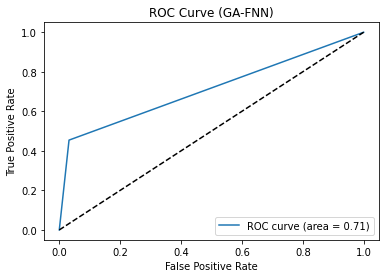

In [31]:
# Calculate the ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred)

# Create ROC curve plot
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (GA-FNN)')
plt.legend(loc='lower right')
plt.show()

In [29]:
sensitivity = tp/(tp+fn)
precision = tp/(tp+fp)
recall=tp/(tp + tn)
f1_score = 2*(precision * recall)/(precision+recall)

In [30]:
# Print the results
print("Sensitivity:", sensitivity)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Sensitivity: 0.454320987654321
Precision: 0.7829787234042553
Recall: 0.10648148148148148
F1 Score: 0.18746816097809477


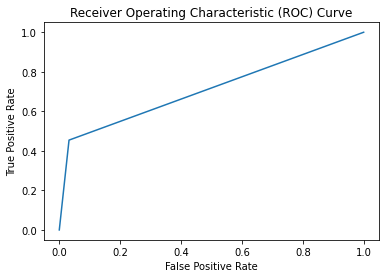

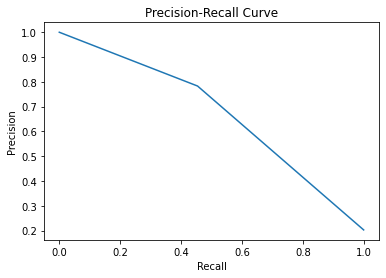

In [28]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# Assuming you have the true labels (y_true) and predicted probabilities (y_pred)
# for the positive class from your model

# Compute ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred)

# Compute precision-recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

# Plot PR curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()
